# **Data Preprocessing & Outlier Handling**
Dataset: Google Play Store Apps

**Importing Required Libraries**

Explanation:
We import all necessary libraries for data manipulation, cleaning, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set(style='whitegrid', palette='crest')


**Load Dataset**

Explanation:
Load the dataset and view a preview to confirm successful import.

In [2]:
  import kagglehub
  import pandas as pd
  import os

  # Download latest version
  path = kagglehub.dataset_download("meenakshsinghania/googleplaystore")

  print("Path to dataset files:", path)
  for file in os.listdir(path):
      if file.endswith(".csv"):
          csv_path = os.path.join(path, file)
          break

  # Load the dataset
  apps = pd.read_csv(csv_path)
  apps.head()


Path to dataset files: /Users/saivikas/.cache/kagglehub/datasets/meenakshsinghania/googleplaystore/versions/1


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


**Dataset Overview**

Explanation:
Get basic details about data shape, column types, and missing values.

In [3]:
print("Dataset Shape:", apps.shape)
apps.info()
apps.describe(include='all').T.head(10)


Dataset Shape: (10841, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
App,10841,9660,ROBLOX,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,10841,34,FAMILY,1972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9367.0,NaN,NaN,NaN,4.193338,0.537431,1.0,4.0,4.3,4.5,19.0
Reviews,10841,6002,0,596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Size,10841,462,Varies with device,1695,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Installs,10841,22,"1,000,000+",1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10840,3,Free,10039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,10841,93,0,10040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Content Rating,10840,6,Everyone,8714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genres,10841,120,Tools,842,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Removing Duplicates**

Explanation:
We remove duplicate rows to ensure data uniqueness.

In [4]:
duplicates_before = apps.duplicated().sum()
print(f"Duplicates before removal: {duplicates_before}")

apps.drop_duplicates(inplace=True)

duplicates_after = apps.duplicated().sum()
print(f"Duplicates after removal: {duplicates_after}")
print(f"Rows reduced to: {apps.shape[0]}")


Duplicates before removal: 483
Duplicates after removal: 0
Rows reduced to: 10358


**Handling Missing Values**

Explanation:
Detect and handle missing values by dropping essential ones and filling others using mean/median/mode.

In [5]:
print("Missing values before:\n", apps.isnull().sum()[apps.isnull().sum() > 0])

apps.dropna(subset=["App", "Category"], inplace=True)
apps["Rating"].fillna(apps["Rating"].median(), inplace=True)
apps["Current Ver"].fillna(apps["Current Ver"].mode()[0], inplace=True)
apps["Android Ver"].fillna(apps["Android Ver"].mode()[0], inplace=True)

print("\n Missing values handled successfully!")


Missing values before:
 Rating            1465
Type                 1
Content Rating       1
Current Ver          8
Android Ver          3
dtype: int64

 Missing values handled successfully!


/var/folders/cy/9fmnck0d3f787y1hg127x06c0000gn/T/ipykernel_2184/406377165.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps["Rating"].fillna(apps["Rating"].median(), inplace=True)
/var/folders/cy/9fmnck0d3f787y1hg127x06c0000gn/T/ipykernel_2184/406377165.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

**Cleaning and Converting Data Types**

Explanation:
Convert string columns like Installs, Price, and Size into numeric formats suitable for analysis.

In [6]:

# --- Clean Installs ---
apps["Installs"] = (
    apps["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Replace text or invalid entries like 'Free' with NaN
apps.loc[~apps["Installs"].str.match(r'^\d+$'), "Installs"] = np.nan

# Convert to float safely
apps["Installs"] = pd.to_numeric(apps["Installs"], errors="coerce")

# --- Clean Price ---
apps["Price"] = (
    apps["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace("Free", "0", regex=False)
    .str.strip()
)

apps["Price"] = pd.to_numeric(apps["Price"], errors="coerce")

# --- Convert Size to MB ---
def size_to_mb(size):
    size = str(size).strip()
    if "M" in size:
        return float(size.replace("M", ""))
    elif "k" in size:
        return float(size.replace("k", "")) / 1024
    elif size.isdigit():
        return float(size)
    else:
        return np.nan

apps["Size"] = apps["Size"].apply(size_to_mb)
apps["Size"].fillna(apps["Size"].median(), inplace=True)

print("Data type conversion complete!")
apps[["Installs", "Price", "Size"]].head()



Data type conversion complete!


/var/folders/cy/9fmnck0d3f787y1hg127x06c0000gn/T/ipykernel_2184/3450448851.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  apps["Size"].fillna(apps["Size"].median(), inplace=True)


,Installs,Price,Size
0,10000.0,0.0,19.0
1,500000.0,0.0,14.0
2,5000000.0,0.0,8.7
3,50000000.0,0.0,25.0
4,100000.0,0.0,2.8


**Handling Invalid / Negative Values**

Explanation:
Remove invalid values like negative reviews, ratings > 5, or impossible installs.

In [7]:
apps["Reviews"] = pd.to_numeric(apps["Reviews"], errors="coerce")
apps = apps[(apps["Rating"].between(0,5)) & (apps["Reviews"] >= 0) & (apps["Installs"] >= 0)]

print("Invalid/Negative values removed.")


Invalid/Negative values removed.


**Feature Engineering**

Explanation:
Add new features like estimated revenue, update month, and binary indicator for paid apps.

In [8]:
apps["Revenue_Estimate"] = apps["Installs"] * apps["Price"]
apps["Last_Updated_Month"] = pd.to_datetime(apps["Last Updated"]).dt.month_name()
apps["Type_Binary"] = apps["Type"].apply(lambda x: 1 if x == "Paid" else 0)

apps[["App", "Installs", "Price", "Revenue_Estimate", "Last_Updated_Month", "Type_Binary"]].head()


,App,Installs,Price,Revenue_Estimate,Last_Updated_Month,Type_Binary
0,Photo Editor & Candy Camera & Grid & ScrapBook,10000.0,0.0,0.0,January,0
1,Coloring book moana,500000.0,0.0,0.0,January,0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",5000000.0,0.0,0.0,August,0
3,Sketch - Draw & Paint,50000000.0,0.0,0.0,June,0
4,Pixel Draw - Number Art Coloring Book,100000.0,0.0,0.0,June,0


**Outlier Detection & Handling (IQR Method)**

Explanation:
We’ll detect outliers using the Interquartile Range (IQR) for continuous numeric columns and visualize them before and after removal.

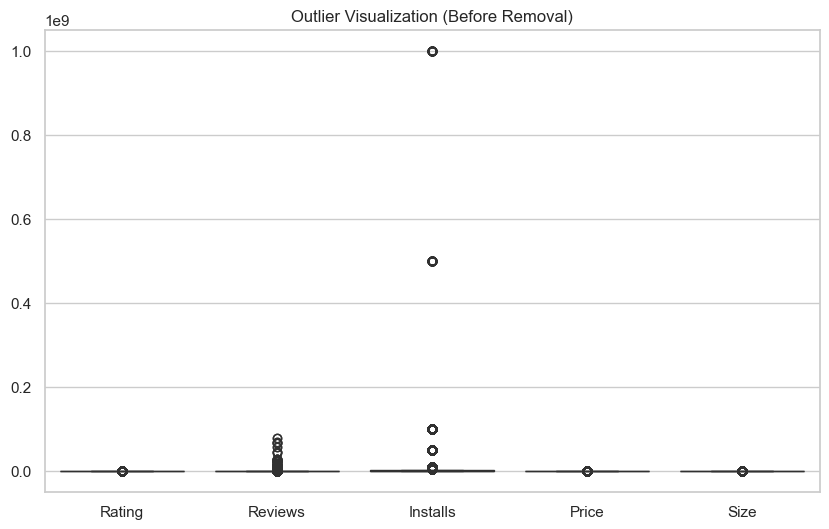

Rating: Removed 723 outliers
Reviews: Removed 1709 outliers
Installs: Removed 848 outliers
Price: Removed 708 outliers
Size: Removed 423 outliers


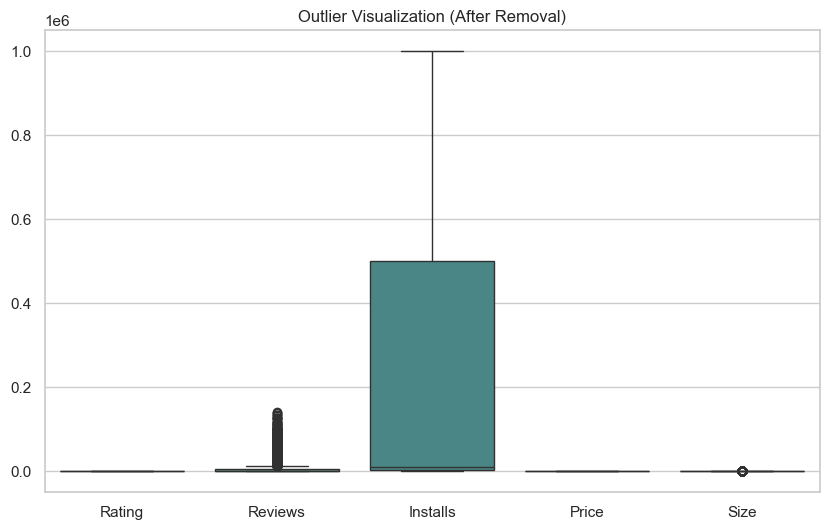

Outliers handled successfully!


In [9]:
numeric_cols = ["Rating", "Reviews", "Installs", "Price", "Size"]

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    before = df.shape[0]
    df = df[(df[col] >= lower) & (df[col] <= upper)]
    after = df.shape[0]

    print(f"{col}: Removed {before - after} outliers")
    return df

# Visualize outliers before removal
plt.figure(figsize=(10,6))
sns.boxplot(data=apps[numeric_cols])
plt.title("Outlier Visualization (Before Removal)")
plt.show()

# Remove outliers
for col in numeric_cols:
    apps = remove_outliers_iqr(apps, col)

# Visualize after removal
plt.figure(figsize=(10,6))
sns.boxplot(data=apps[numeric_cols])
plt.title("Outlier Visualization (After Removal)")
plt.show()

print("Outliers handled successfully!")


**Final Dataset Summary**

Explanation:
Check the dataset’s final shape and ensure no extreme values remain.

In [10]:
print("Final Dataset Shape:", apps.shape)
apps.describe().T


Final Dataset Shape: (5946, 16)


,count,mean,std,min,25%,50%,75%,max
Rating,5946.0,4.284595,0.326489,3.500000,4.100,4.3,4.5,5.0
Reviews,5946.0,7072.209384,16526.134890,0.000000,10.000,230.5,4793.5,140658.0
Size,5946.0,13.835348,12.084969,0.008301,4.225,11.0,20.0,53.0
Installs,5946.0,261052.604776,397688.795071,0.000000,1000.000,10000.0,500000.0,1000000.0
Price,5946.0,0.000000,0.000000,0.000000,0.000,0.0,0.0,0.0
Revenue_Estimate,5946.0,0.000000,0.000000,0.000000,0.000,0.0,0.0,0.0
Type_Binary,5946.0,0.000000,0.000000,0.000000,0.000,0.0,0.0,0.0


In [11]:
apps.to_csv("googleplaystore_cleaned.csv", index=False)
print("Saved cleaned dataset as 'googleplaystore_cleaned.csv'")


Saved cleaned dataset as 'googleplaystore_cleaned.csv'


## **Exploratory Data Analysis & Visualizations**
Below are 15 key visualizations to explore your cleaned dataset and validate preprocessing quality.

Rating Distribution

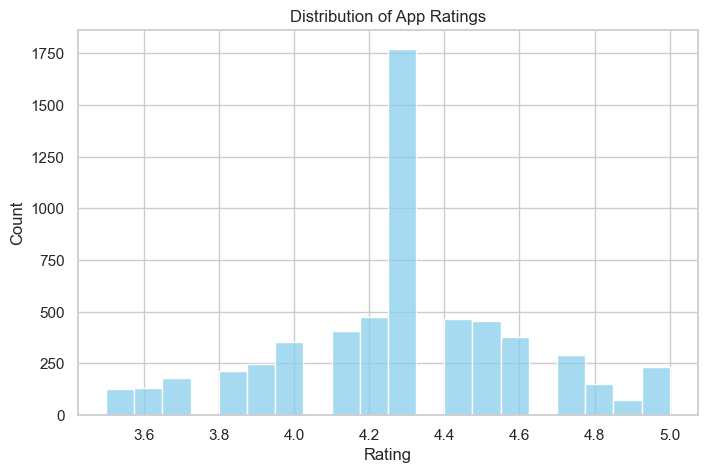

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(apps["Rating"], bins=20, color="skyblue")
plt.title("Distribution of App Ratings")
plt.show()


Category-wise App Count

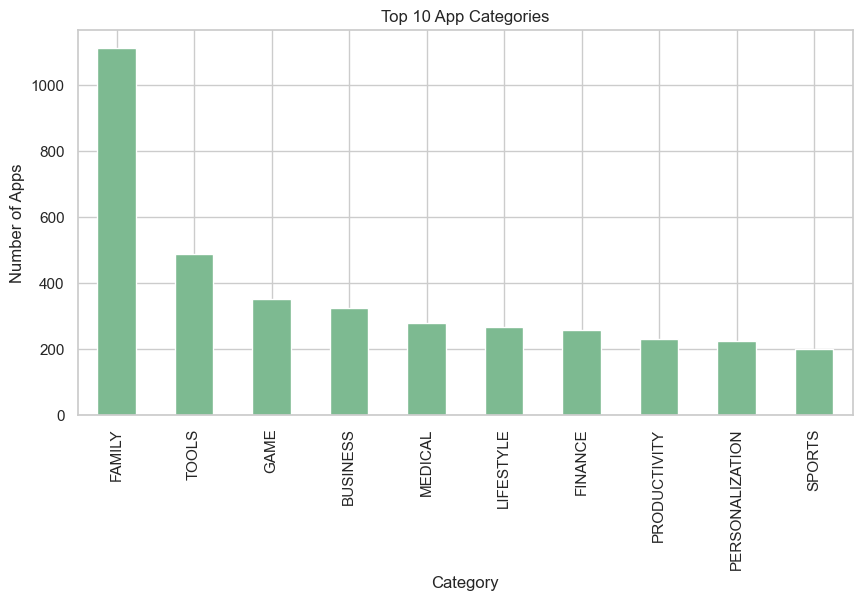

In [13]:
plt.figure(figsize=(10,5))
apps["Category"].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 App Categories")
plt.ylabel("Number of Apps")
plt.show()


Average Rating by Category

/var/folders/cy/9fmnck0d3f787y1hg127x06c0000gn/T/ipykernel_2184/2789945598.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Rating", y="Category", data=apps, ci=None,


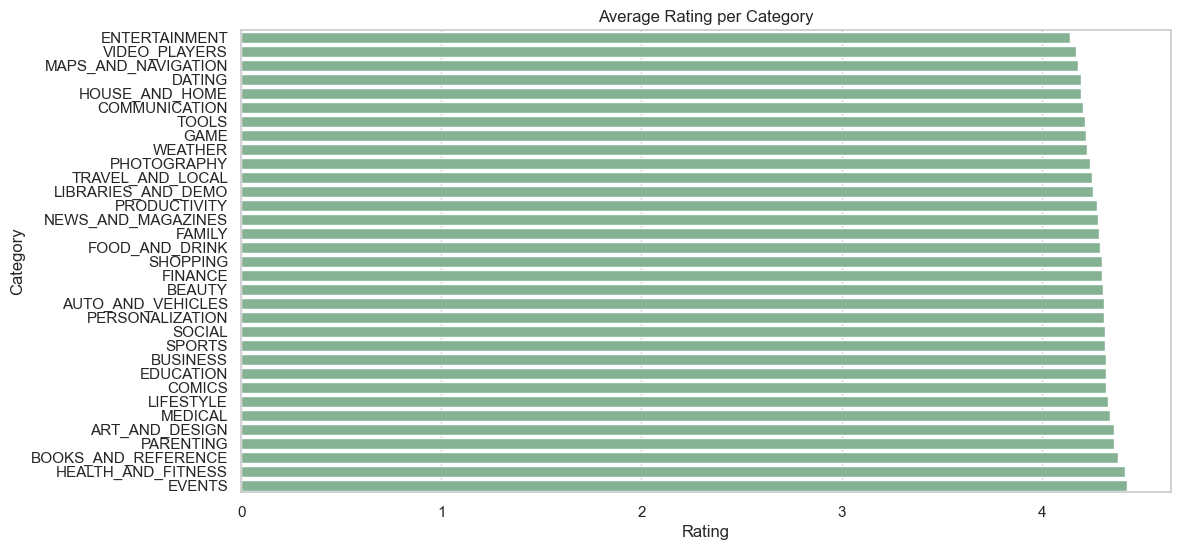

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(x="Rating", y="Category", data=apps, ci=None,
            order=apps.groupby("Category")["Rating"].mean().sort_values().index)
plt.title("Average Rating per Category")
plt.show()


Installs vs Rating

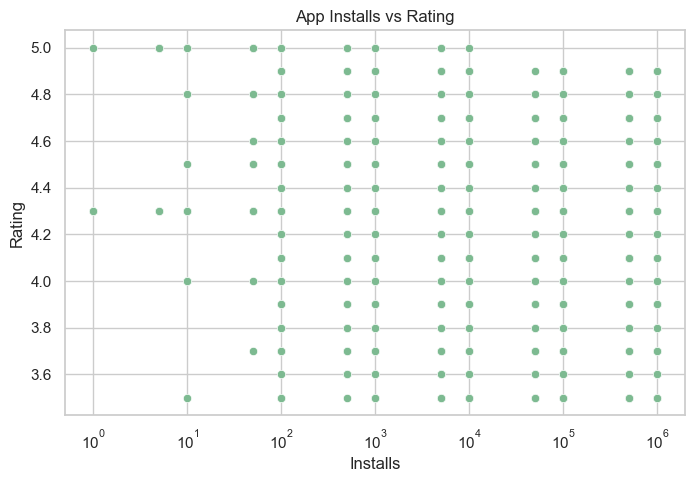

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Installs", y="Rating", data=apps)
plt.xscale("log")
plt.title("App Installs vs Rating")
plt.show()


App Type Distribution

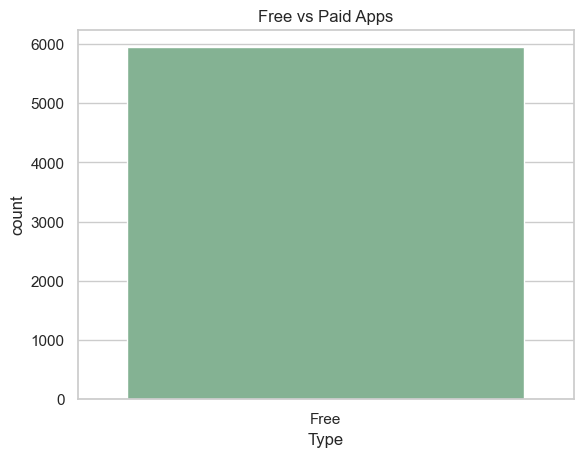

In [16]:
sns.countplot(x="Type", data=apps)
plt.title("Free vs Paid Apps")
plt.show()


App Size vs Rating

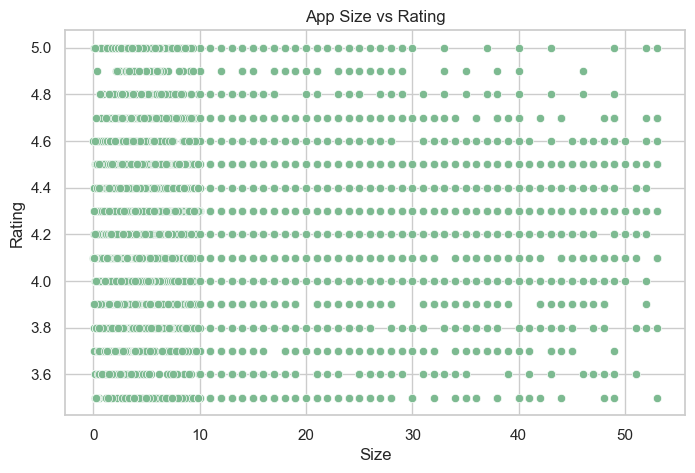

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Size", y="Rating", data=apps)
plt.title("App Size vs Rating")
plt.show()


Reviews vs Installs

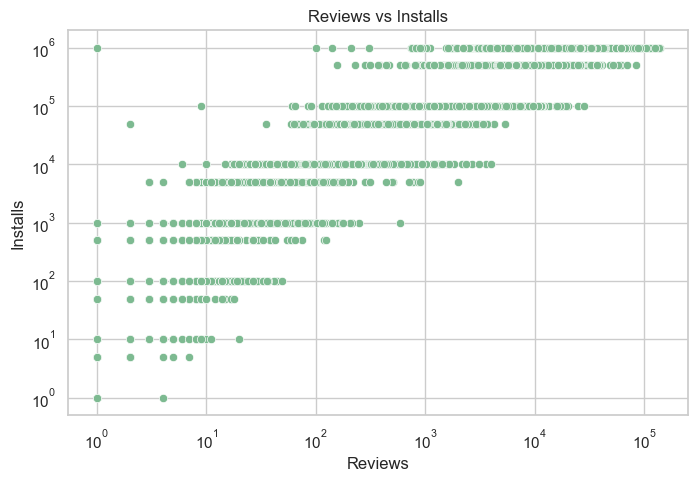

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Reviews", y="Installs", data=apps)
plt.xscale("log")
plt.yscale("log")
plt.title("Reviews vs Installs")
plt.show()


Rating Distribution by Content Rating

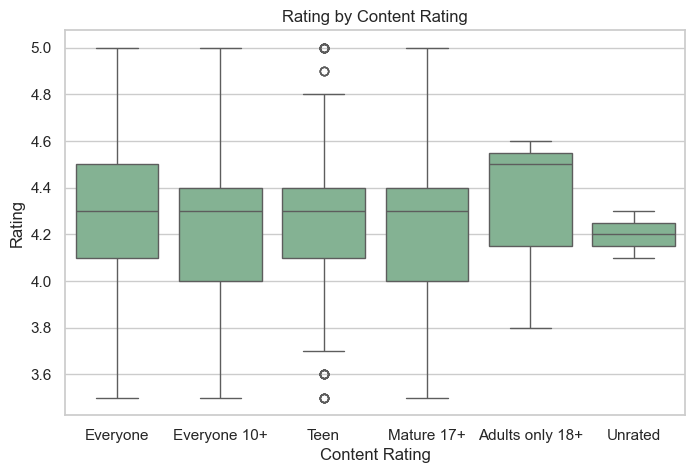

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Content Rating", y="Rating", data=apps)
plt.title("Rating by Content Rating")
plt.show()


Top 10 Genres

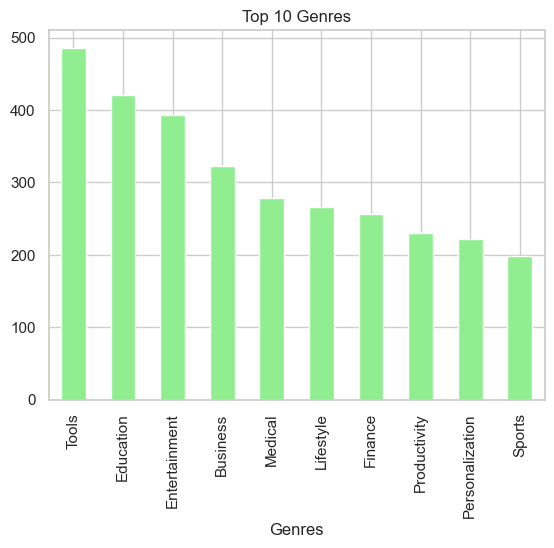

In [20]:
apps["Genres"].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title("Top 10 Genres")
plt.show()


Correlation Heatmap

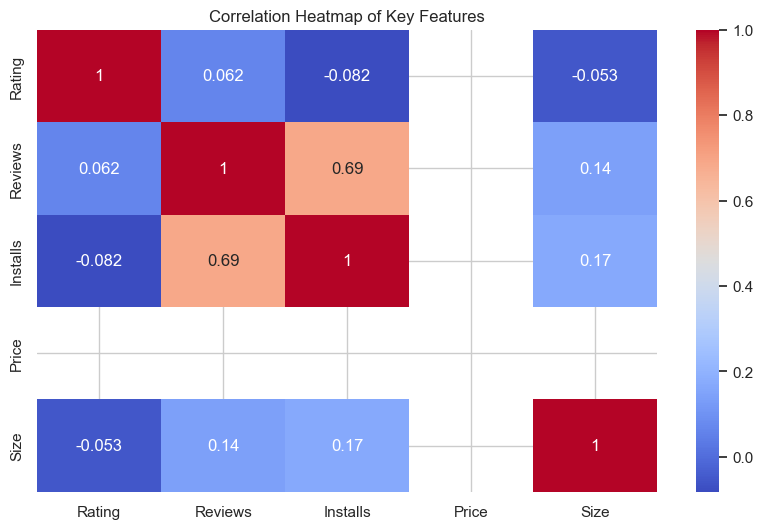

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(apps[["Rating", "Reviews", "Installs", "Price", "Size"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Key Features")
plt.show()


Installs by Category

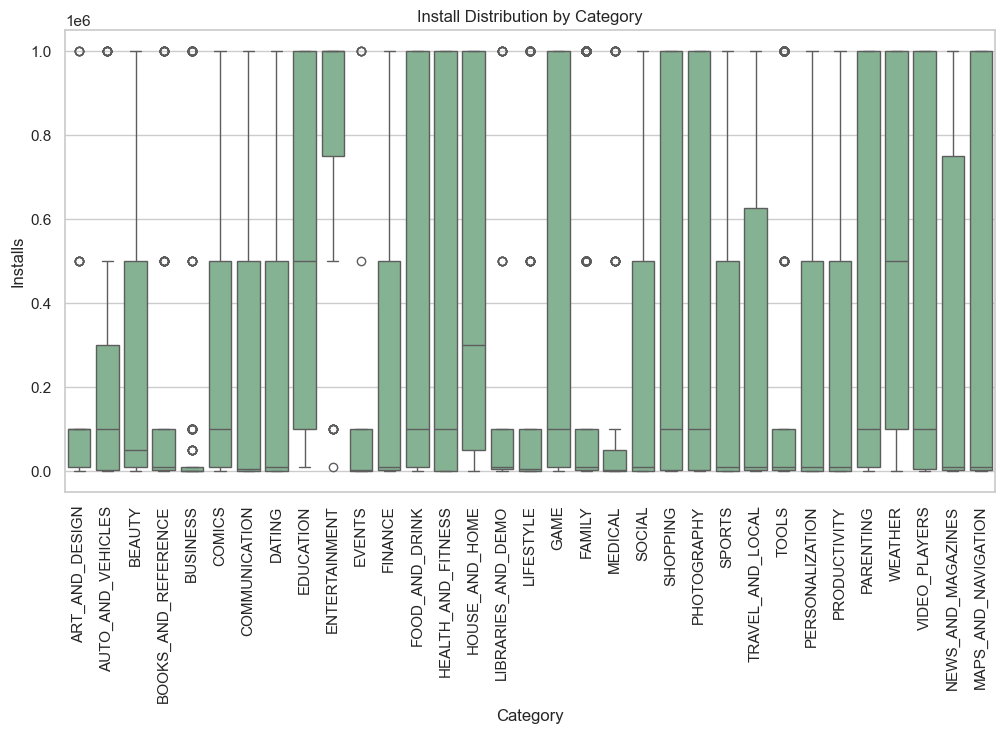

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Category", y="Installs", data=apps)
plt.xticks(rotation=90)
plt.title("Install Distribution by Category")
plt.show()

Updates Trend by Month

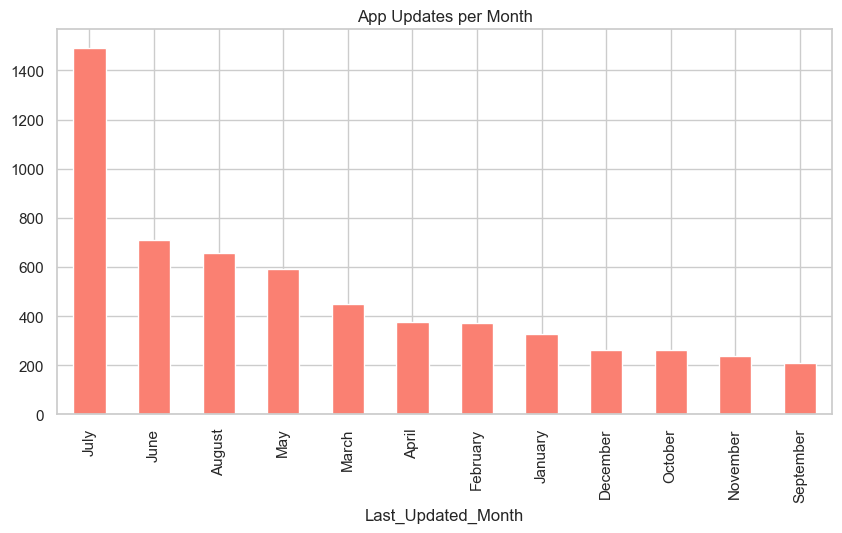

In [23]:
apps["Last_Updated_Month"].value_counts().plot(kind='bar', figsize=(10,5), color='salmon')
plt.title("App Updates per Month")
plt.show()

Average Installs by App Type

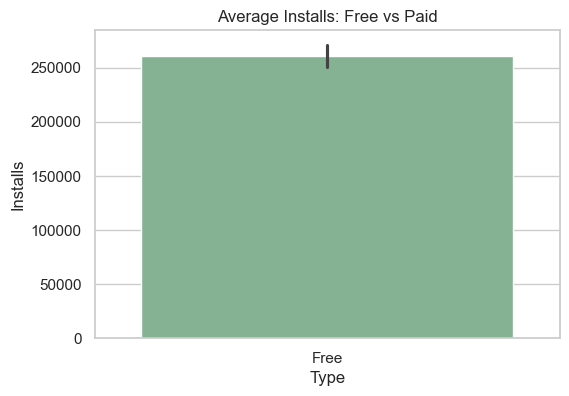

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(x="Type", y="Installs", data=apps, estimator=np.mean)
plt.title("Average Installs: Free vs Paid")
plt.show()
